In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

In [2]:
df = pd.read_csv("proteinbase_all_data.csv")
df

,id,name,sequence,author,designMethod,evaluations
0,gentle-cobra-lotus,PD-L1,ESGYAQNGDLEDAELDDYSFSCYSQLEVNGSQHSLTCAFEDPDVNI...,NaN,NaN,"[{""type"":""computational"",""value"":""Not Assigned..."
1,jade-otter-jade,1.3.3.18_2431_12,TAPESNYCLNETVIDCPTSHDTFCLYDGTCMFIPEMEKYACNCLAG...,crg-ferruz-lab,protrl,"[{""type"":""experimental"",""value"":true,""metric"":..."
2,violet-ram-dust,1.3.3.18_4149_15,SPETDTINGLAKCPEEYIHFCIHGVCKFIQEQETPSCRCNKGYNGSRCE,crg-ferruz-lab,protrl,"[{""type"":""experimental"",""value"":true,""metric"":..."
3,dark-orca-crystal,1.3.3.18_1221_0,SNTVERCPSAHDTYCLYGGVCFYIPELQQYACNCVPGYVGERCQYS...,crg-ferruz-lab,protrl,"[{""type"":""experimental"",""value"":false,""metric""..."
4,soft-raven-frost,1.3.3.18_1409_17,SGPLRSPEPATDFPGRGLPCPVDHYCLNGGRCKFLEELQEYACECV...,crg-ferruz-lab,protrl,"[{""type"":""experimental"",""value"":true,""metric"":..."
...,...,...,...,...,...,...
1045,violet-moth-crystal,GPLSKAEYLEEQIKFVEENKDKKELVKPKLIETLKYVGYDEEAEYY...,GPLSKAEYLEEQIKFVEENKDKKELVKPKLIETLKYVGYDEEAEYY...,escalante-bio,mosaic,"[{""type"":""experimental"",""value"":true,""metric"":..."
1046,steady-bat-crystal,EVNCELLNKLAEPVAKELFPENDLAKISTFYAALFFAYEGALKGKP...,EVNCELLNKLAEPVAKELFPENDLAKISTFYAALFFAYEGALKGKP...,escalante-bio,mosaic,"[{""type"":""experimental"",""value"":true,""metric"":..."
1047,small-quail-opal,ALSEAEKKTIVGTAEAFARYALRYRKTKDPEDKWAVDTLLWMFESS...,ALSEAEKKTIVGTAEAFARYALRYRKTKDPEDKWAVDTLLWMFESS...,escalante-bio,mosaic,"[{""type"":""experimental"",""value"":true,""metric"":..."
1048,green-raven-ember,PD-L1,WQAYNKGMYVDKFRAEIVRFHHDQNPYMYIIWQWLVHVPPKVVKRR...,NaN,NaN,"[{""type"":""computational"",""value"":""Not Assigned..."


In [3]:
import json

df["evaluations"] = df["evaluations"].apply(json.loads)

# print(type(alldata.loc[0, "evaluations"]))

df_metrics = df.explode("evaluations", ignore_index=True)
df_metrics = df_metrics.join(pd.json_normalize(df_metrics.pop("evaluations")))
df_metrics

,id,name,sequence,author,designMethod,type,value,metric,valueType,unit,value.url,target
0,gentle-cobra-lotus,PD-L1,ESGYAQNGDLEDAELDDYSFSCYSQLEVNGSQHSLTCAFEDPDVNI...,NaN,NaN,computational,Not Assigned,design_class,label,NaN,NaN,NaN
1,gentle-cobra-lotus,PD-L1,ESGYAQNGDLEDAELDDYSFSCYSQLEVNGSQHSLTCAFEDPDVNI...,NaN,NaN,computational,25259.3216,molecular_weight,numeric,Da,NaN,NaN
2,gentle-cobra-lotus,PD-L1,ESGYAQNGDLEDAELDDYSFSCYSQLEVNGSQHSLTCAFEDPDVNI...,NaN,NaN,computational,5.340501,isoelectric_point,numeric,pH,NaN,NaN
3,gentle-cobra-lotus,PD-L1,ESGYAQNGDLEDAELDDYSFSCYSQLEVNGSQHSLTCAFEDPDVNI...,NaN,NaN,computational,57.84548,esmfold_plddt,numeric,%,NaN,NaN
4,gentle-cobra-lotus,PD-L1,ESGYAQNGDLEDAELDDYSFSCYSQLEVNGSQHSLTCAFEDPDVNI...,NaN,NaN,computational,Eeeeee,foldstring,label,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
45946,small-crow-marble,EGFR,LMFTHKRCCNFSWENDVYKDCFMITSVYMRPKSKETHAEGMVDAVW...,NaN,NaN,computational,2.7348,proteinmpnn_score,numeric,NaN,NaN,NaN
45947,small-crow-marble,EGFR,LMFTHKRCCNFSWENDVYKDCFMITSVYMRPKSKETHAEGMVDAVW...,NaN,NaN,computational,1.42608,redesigned_proteinmpnn_score,numeric,NaN,NaN,NaN
45948,small-crow-marble,EGFR,LMFTHKRCCNFSWENDVYKDCFMITSVYMRPKSKETHAEGMVDAVW...,NaN,NaN,computational,0.16866,proteinmpnn_seq_recovery,numeric,%,NaN,NaN
45949,small-crow-marble,EGFR,LMFTHKRCCNFSWENDVYKDCFMITSVYMRPKSKETHAEGMVDAVW...,NaN,NaN,computational,NaN,esmfold_structure_prediction,json,NaN,https://proteinbase-pub.t3.storage.dev/01K6MZG...,NaN


In [4]:
nan_designs = df_metrics[df_metrics["designMethod"].isna()]
nan_designs

,id,name,sequence,author,designMethod,type,value,metric,valueType,unit,value.url,target
0,gentle-cobra-lotus,PD-L1,ESGYAQNGDLEDAELDDYSFSCYSQLEVNGSQHSLTCAFEDPDVNI...,NaN,NaN,computational,Not Assigned,design_class,label,NaN,NaN,NaN
1,gentle-cobra-lotus,PD-L1,ESGYAQNGDLEDAELDDYSFSCYSQLEVNGSQHSLTCAFEDPDVNI...,NaN,NaN,computational,25259.3216,molecular_weight,numeric,Da,NaN,NaN
2,gentle-cobra-lotus,PD-L1,ESGYAQNGDLEDAELDDYSFSCYSQLEVNGSQHSLTCAFEDPDVNI...,NaN,NaN,computational,5.340501,isoelectric_point,numeric,pH,NaN,NaN
3,gentle-cobra-lotus,PD-L1,ESGYAQNGDLEDAELDDYSFSCYSQLEVNGSQHSLTCAFEDPDVNI...,NaN,NaN,computational,57.84548,esmfold_plddt,numeric,%,NaN,NaN
4,gentle-cobra-lotus,PD-L1,ESGYAQNGDLEDAELDDYSFSCYSQLEVNGSQHSLTCAFEDPDVNI...,NaN,NaN,computational,Eeeeee,foldstring,label,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
45946,small-crow-marble,EGFR,LMFTHKRCCNFSWENDVYKDCFMITSVYMRPKSKETHAEGMVDAVW...,NaN,NaN,computational,2.7348,proteinmpnn_score,numeric,NaN,NaN,NaN
45947,small-crow-marble,EGFR,LMFTHKRCCNFSWENDVYKDCFMITSVYMRPKSKETHAEGMVDAVW...,NaN,NaN,computational,1.42608,redesigned_proteinmpnn_score,numeric,NaN,NaN,NaN
45948,small-crow-marble,EGFR,LMFTHKRCCNFSWENDVYKDCFMITSVYMRPKSKETHAEGMVDAVW...,NaN,NaN,computational,0.16866,proteinmpnn_seq_recovery,numeric,%,NaN,NaN
45949,small-crow-marble,EGFR,LMFTHKRCCNFSWENDVYKDCFMITSVYMRPKSKETHAEGMVDAVW...,NaN,NaN,computational,NaN,esmfold_structure_prediction,json,NaN,https://proteinbase-pub.t3.storage.dev/01K6MZG...,NaN


In [5]:
def drop_columns(df, columns):
    """
    Drop the specified columns from a pandas dataframe.
    """
    return df.drop(columns=columns, axis=1, errors='ignore')

columns_to_drop = ['author', 'designMethod', 'sequence']
nan_filtered = drop_columns(nan_designs, columns_to_drop)

In [6]:
print(nan_filtered["metric"].unique())
nan_filtered["metric"].value_counts()

['design_class' 'molecular_weight' 'isoelectric_point' 'esmfold_plddt'
 'foldstring' 'classification' 'ted_confidence' 'seqidentity' 'evalue'
 'tm_score' 'rmsd' 'aligned_length' 'cath_detail' 'proteinmpnn_score'
 'redesigned_proteinmpnn_score' 'proteinmpnn_seq_recovery'
 'esmfold_structure_prediction' 'esmfold_stylized_image'
 'seqidentityafdb50' 'evalueafdb50' 'tm-scoreafdb50' 'rmsdafdb50'
 'aligned-lengthafdb50' 'seqidentitycath50' 'evaluecath50'
 'tm-scorecath50' 'rmsdcath50' 'aligned-lengthcath50' 'seqidentitypdb100'
 'evaluepdb100' 'tm-scorepdb100' 'rmsdpdb100' 'aligned-lengthpdb100'
 'expressed' 'binding' 'binding_strength' 'bli_kinetic_curves' 'kd' 'kon'
 'koff' nan]


metric
bli_kinetic_curves              1263
expressed                       1263
esmfold_plddt                   1206
binding                         1177
binding_strength                1176
ted_confidence                   653
classification                   653
foldstring                       653
cath_detail                      622
rmsdcath50                       617
tm-scorecath50                   617
evaluecath50                     617
aligned-lengthcath50             617
seqidentitycath50                617
aligned-lengthafdb50             609
tm-scoreafdb50                   609
seqidentityafdb50                609
rmsdafdb50                       609
evalueafdb50                     609
seqidentitypdb100                603
aligned-lengthpdb100             603
tm-scorepdb100                   603
evaluepdb100                     603
rmsdpdb100                       603
esmfold_stylized_image           553
design_class                     553
molecular_weight               

In [7]:
metrics_of_interest = ["esmfold_plddt", "proteinmpnn_score", "design_class"]
subset = nan_filtered[nan_filtered["metric"].isin(metrics_of_interest)].copy()

subset_pivot = subset.pivot_table(index="id", columns="metric", values="value", aggfunc="first").reset_index()
print(subset_pivot["design_class"].unique())
subset_pivot


['Peptide' 'Miniprotein' 'Nanobody' 'Not Assigned' 'Scfv']


metric,id,design_class,esmfold_plddt,proteinmpnn_score
0,amber-bat-stone,Peptide,55.739531,2.2553
1,amber-bear-snow,Miniprotein,77.015284,1.8785
2,amber-bison-leaf,Miniprotein,87.852087,1.5017
3,amber-crane-onyx,Peptide,80.630989,2.1575
4,amber-deer-clay,Nanobody,85.689558,1.2882
...,...,...,...,...
547,young-seal-lotus,Nanobody,89.702941,1.0121
548,young-seal-maple,Not Assigned,83.716732,1.9639
549,young-tiger-reed,Peptide,82.938996,1.7363
550,young-zebra-quartz,Not Assigned,84.875786,1.6898


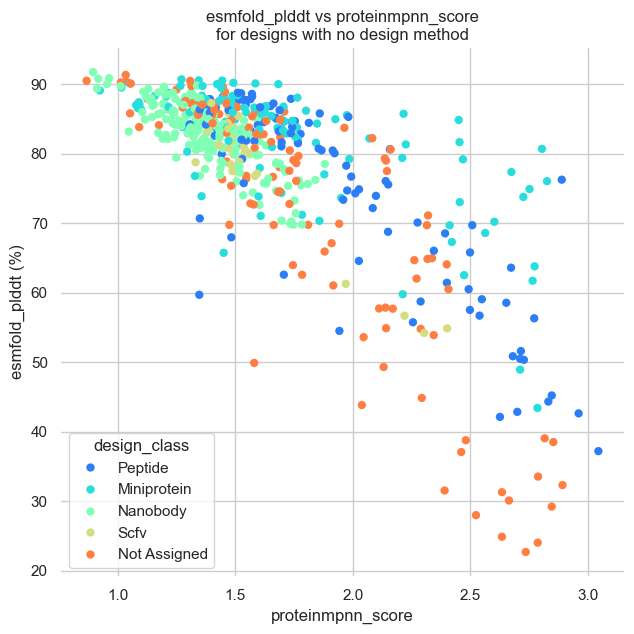

In [8]:
sns.set_theme(style="whitegrid")
f, ax = plt.subplots(figsize=(6.5, 6.5))
sns.despine(f, left=True, bottom=True)
design_class_ranking = ['Peptide', 'Miniprotein', 'Nanobody', 'Scfv', 'Not Assigned']
sns.scatterplot(data=subset_pivot, y="esmfold_plddt", x="proteinmpnn_score", hue="design_class", hue_order=design_class_ranking, palette="rainbow", sizes=(1, 8), linewidth=0, ax=ax)

plt.title("esmfold_plddt vs proteinmpnn_score\nfor designs with no design method")
plt.xlabel("proteinmpnn_score")
plt.ylabel("esmfold_plddt (%)")
plt.tight_layout()
# plt.savefig("plots_no_designM/esmfold_vs_proteinmpnn_no_designM.png")
plt.show()